# EXP-030 — Dual-Cp pressure-conditioning explorer

Two stacked Cp(x/c) editors. The **top** controls the upper surface, the **bottom** controls the lower surface. Together they form a 16-mode conditioning vector ``[upper modes (K=8), lower modes (K=8)]`` that the EXP-030 model uses to regenerate boundary shapes.

- **Grey line** in each editor — cubic spline through the draggable handles.
- **Blue / red line** — DCT-8 reconstruction (what the model sees as the upper / lower cond half).
- **CFG slider** — classifier-free-guidance scale.
- **Seed input** — base seed for sampling.
- **Reset dropdown** — pick a training-set Cp pair to start from.

Default checkpoint is **EXP-030** (AoA 0–10° dataset + dual conditioning). If you want to compare against the single-curve EXP-021 model, open [`EXP-020_interactive_cp.ipynb`](EXP-020_interactive_cp.ipynb) instead.

In [1]:
%matplotlib widget
import copy
import sys
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve the repo root by walking up to the pyproject.toml, so the
# notebook works whether the kernel starts in notebooks/ or the root.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'pyproject.toml').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from graph_diffusion.data.pOnEllipseConditional import dct_ii_inverse
from graph_diffusion.postprocessing.inference import (
    radial_to_xy, sample_shapes_from_cond, template_thetas,
)
from graph_diffusion.postprocessing.loaders import load_exp020
from graph_diffusion.visualisation.cp_editor import CpCurveEditor

/home/m22729ad/Projects-Local/DGN_Sup/.venv/lib/python3.13/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/m22729ad/Projects-Local/DGN_Sup/.venv/lib/python3.13/site-packages/libpyg.so: undefined symbol: _ZN2at4_ops11multinomial4callERKNS_6TensorElbSt8optionalINS_9GeneratorEE
  import torch_geometric.typing


In [2]:
# Configuration --------------------------------------------------------------
EXPERIMENT_DIR = str(REPO_ROOT / 'outputs/EXP-030_dual_cp')
CONFIG_PATH    = str(REPO_ROOT / 'configs/EXP-030_dual_cp.yaml')
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES      = 4
CLAMP_RANGE    = (0.5, 2.0)
N_CP_GRID      = 128
K_MODES        = 8

model, dataset, config = load_exp020(
    experiment_dir=EXPERIMENT_DIR,
    config_path=CONFIG_PATH,
    device=DEVICE,
)
template = copy.copy(dataset[0]).to(DEVICE)
theta = template_thetas(template)

# Sanity check: dataset must be in fourier_dual mode.
assert dataset.cond_mode == 'fourier_dual', (
    f'Expected cond_mode=fourier_dual, got {dataset.cond_mode}. '
    'Are you pointing at the right config?'
)
print(f'device={DEVICE}  N_nodes={template.pos.shape[0]}  '
      f'K={K_MODES}  T={model.noise_schedule.T}  '
      f"cond_dim={dataset[0].cond.shape[1]}")

Loaded checkpoint from: /home/m22729ad/Projects-Local/DGN_Sup/outputs/EXP-030_dual_cp/checkpoint_best.pt
Epoch: 400, Learning Rate: 0.001
device=cuda  N_nodes=60  K=8  T=200  cond_dim=16


In [3]:
# Initial Cp = dataset mean (so the first shapes look ellipse-like).
mean_cond = torch.stack(
    [g.cond.squeeze(0) for g in dataset], dim=0,
).mean(dim=0).numpy()
initial_upper = dct_ii_inverse(mean_cond[:K_MODES], N_CP_GRID)
initial_lower = dct_ii_inverse(mean_cond[K_MODES:], N_CP_GRID)
print(f'initial upper Cp range: {initial_upper.min():.3f} .. {initial_upper.max():.3f}')
print(f'initial lower Cp range: {initial_lower.min():.3f} .. {initial_lower.max():.3f}')

initial upper Cp range: -0.396 .. 0.300
initial lower Cp range: -0.396 .. 0.296


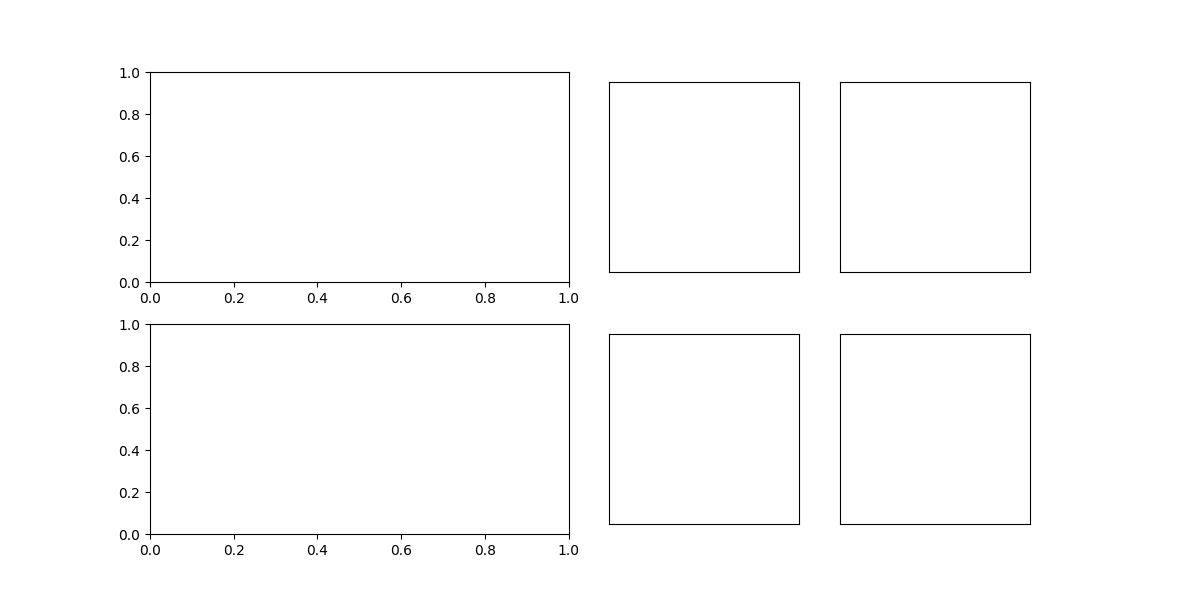

In [4]:
# Layout: two stacked Cp editors (upper, lower) on the left; 2x2 shape grid on the right.
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[2.2, 1, 1, 0.05])
ax_upper = fig.add_subplot(gs[0, 0])
ax_lower = fig.add_subplot(gs[1, 0])
shape_axes = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]
for ax in shape_axes:
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
shape_lines = [None] * N_SAMPLES

cfg_slider = widgets.FloatSlider(
    value=float(config.get('sampling', {}).get('guidance_scale', 3.0)),
    min=1.0, max=7.0, step=0.5, description='CFG w',
)
seed_input = widgets.IntText(value=0, description='Seed')
reset_dropdown = widgets.Dropdown(
    options=[('mean (dataset)', -1)] + [
        (f'train #{i}', i) for i in range(min(20, len(dataset)))
    ],
    value=-1, description='Reset Cp',
)
status_label = widgets.Label(value='Drag a handle on either curve to regenerate shapes.')
controls = widgets.HBox([cfg_slider, seed_input, reset_dropdown, status_label])

In [5]:
def draw_shapes(radii: np.ndarray) -> None:
    for i in range(N_SAMPLES):
        ax = shape_axes[i]
        xy = radial_to_xy(radii[i], theta)
        closed = np.vstack([xy, xy[:1]])
        if shape_lines[i] is None:
            (shape_lines[i],) = ax.plot(closed[:, 0], closed[:, 1], color='C2', lw=1.4)
        else:
            shape_lines[i].set_data(closed[:, 0], closed[:, 1])
        ax.relim()
        ax.autoscale_view()
    fig.canvas.draw_idle()


def current_cond() -> np.ndarray:
    upper_modes = editor_upper.get_cond_vector()
    lower_modes = editor_lower.get_cond_vector()
    return np.concatenate([upper_modes, lower_modes]).astype(np.float32)


def resample(_cond_vec_unused=None) -> None:
    """Sample shapes for the current upper+lower cond vectors."""
    status_label.value = 'Sampling...'
    cond_t = torch.from_numpy(current_cond()).float().to(DEVICE)
    radii, _ = sample_shapes_from_cond(
        model=model,
        template=template,
        cond_vec=cond_t,
        n_samples=N_SAMPLES,
        guidance_scale=float(cfg_slider.value),
        device=DEVICE,
        clamp_range=CLAMP_RANGE,
        seed=int(seed_input.value),
    )
    draw_shapes(radii)
    status_label.value = 'Ready. Drag a handle on either curve to regenerate.'


editor_upper = CpCurveEditor(
    ax=ax_upper,
    initial_cp=initial_upper,
    n_control_points=7,
    k_modes=K_MODES,
    on_release=resample,
)
ax_upper.set_title('Cp (upper surface)')
ax_upper.set_ylim(initial_upper.min() - 1.0, initial_upper.max() + 1.0)

editor_lower = CpCurveEditor(
    ax=ax_lower,
    initial_cp=initial_lower,
    n_control_points=7,
    k_modes=K_MODES,
    on_release=resample,
)
ax_lower.set_title('Cp (lower surface)')
ax_lower.set_ylim(initial_lower.min() - 1.0, initial_lower.max() + 1.0)


def on_reset(change):
    idx = change['new']
    if idx == -1:
        editor_upper.set_cp(initial_upper)
        editor_lower.set_cp(initial_lower)
    else:
        cond_train = dataset[idx].cond.squeeze(0).numpy()
        editor_upper.set_cp(dct_ii_inverse(cond_train[:K_MODES], N_CP_GRID))
        editor_lower.set_cp(dct_ii_inverse(cond_train[K_MODES:], N_CP_GRID))
    resample()

reset_dropdown.observe(on_reset, names='value')
cfg_slider.observe(lambda c: resample(), names='value')
seed_input.observe(lambda c: resample(), names='value')

resample()

display(controls)
plt.tight_layout()